#### Beginning

In [1]:
import pandas as pd

path = r"C:\Users\HP\Python\ml\housing.csv"
data = pd.read_csv(path)

In [2]:
df = pd.DataFrame(data)

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [6]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [7]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


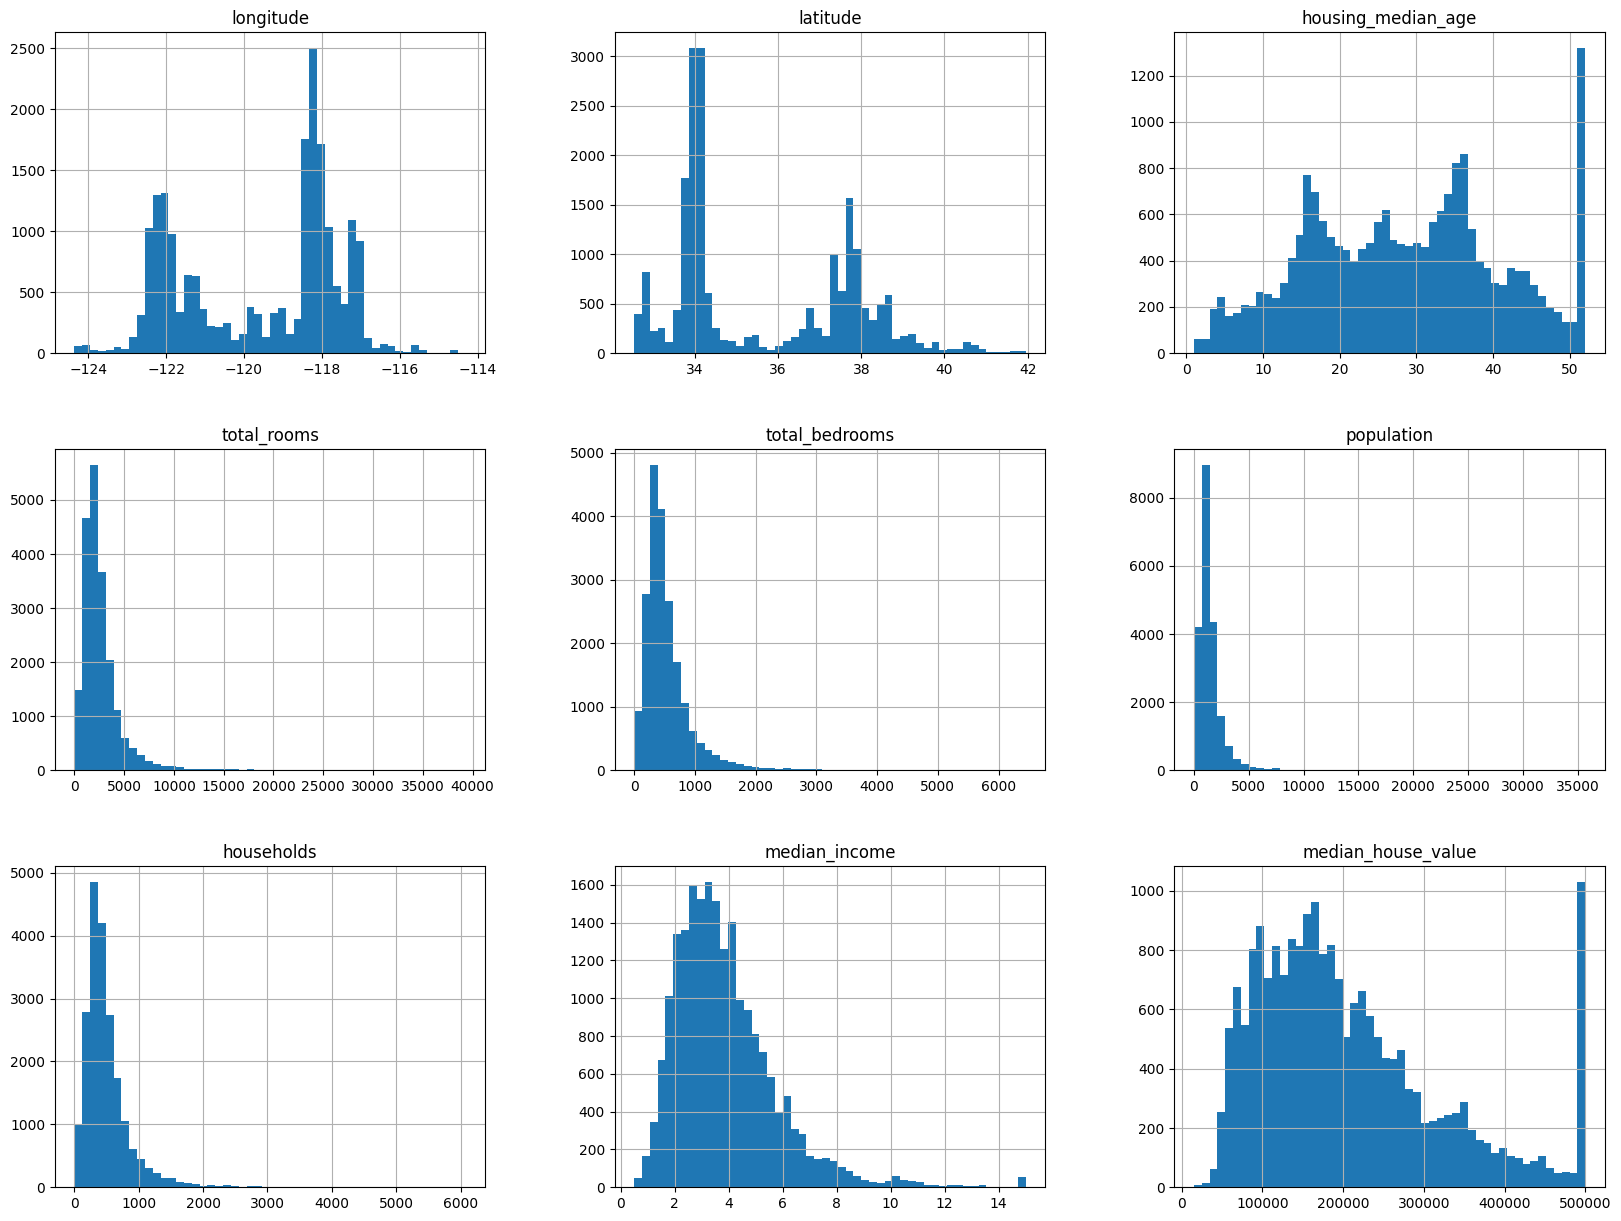

In [8]:
import matplotlib.pyplot as plt

df.hist(bins=50, figsize=(20,15))
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

In [10]:
len(train_set)

16512

In [11]:
len(test_set)

4128

In [12]:
train_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,103000.0,NEAR OCEAN
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,382100.0,NEAR OCEAN
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,172600.0,NEAR OCEAN
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,93400.0,NEAR OCEAN
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,96500.0,INLAND


In [13]:
import numpy as np

In [14]:
df["income_cat"] = np.ceil(df["median_income"] / 1.5)

C:\Users\HP\AppData\Local\Temp\ipykernel_14192\1428313851.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["income_cat"].where(df["income_cat"] < 5, 5.0, inplace=True)


<Axes: >

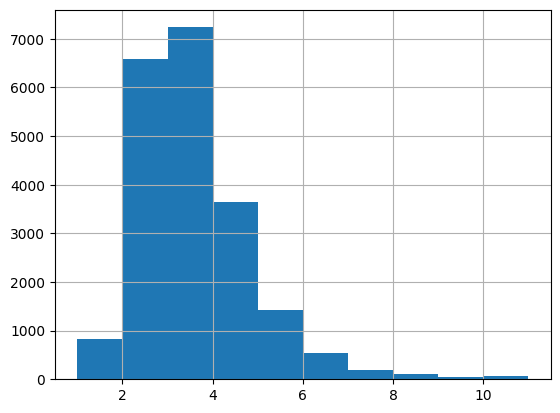

In [15]:
df["income_cat"].where(df["income_cat"] < 5, 5.0, inplace=True)
df["income_cat"].hist()

In [16]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df, df["income_cat"]):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

In [17]:
strat_test_set["income_cat"].value_counts()/ len(strat_test_set)

income_cat
3.0     0.350533
2.0     0.318798
4.0     0.176357
5.0     0.069041
1.0     0.039729
6.0     0.025678
7.0     0.009205
8.0     0.005087
11.0    0.002422
9.0     0.002422
10.0    0.000727
Name: count, dtype: float64

In [18]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [19]:
df = strat_train_set.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

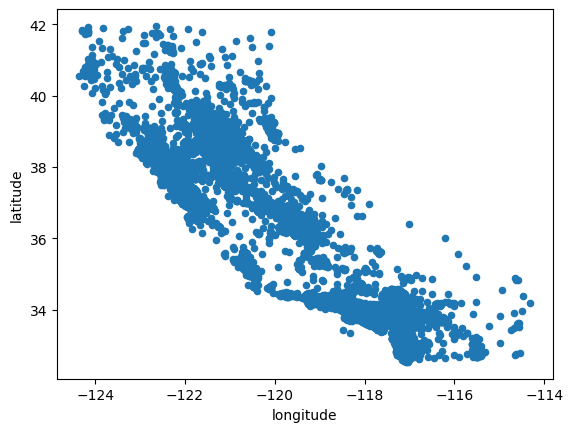

In [20]:
df.plot(kind="scatter", x="longitude", y="latitude")

<Axes: xlabel='longitude', ylabel='latitude'>

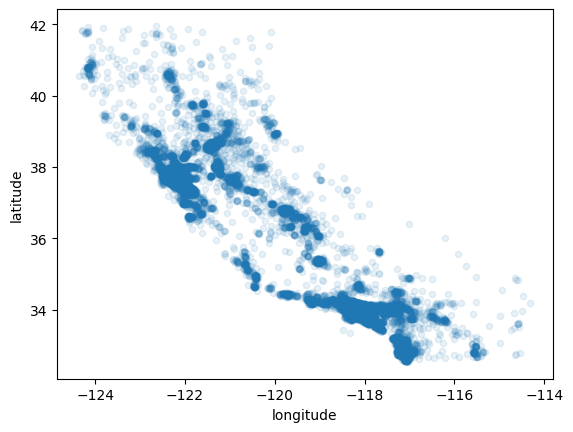

In [21]:
df.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

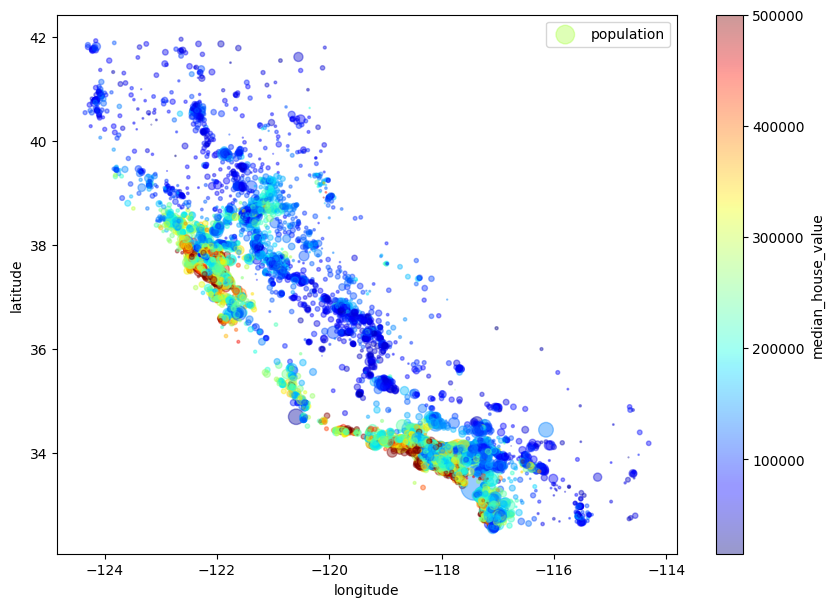

In [22]:
df.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
    s=df["population"]/100, label="population", figsize=(10,7),
    c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
)
plt.legend()

In [23]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()

In [24]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687474
total_rooms           0.135989
housing_median_age    0.111770
households            0.065841
total_bedrooms        0.049177
population           -0.024765
longitude            -0.045056
latitude             -0.144684
Name: median_house_value, dtype: float64

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

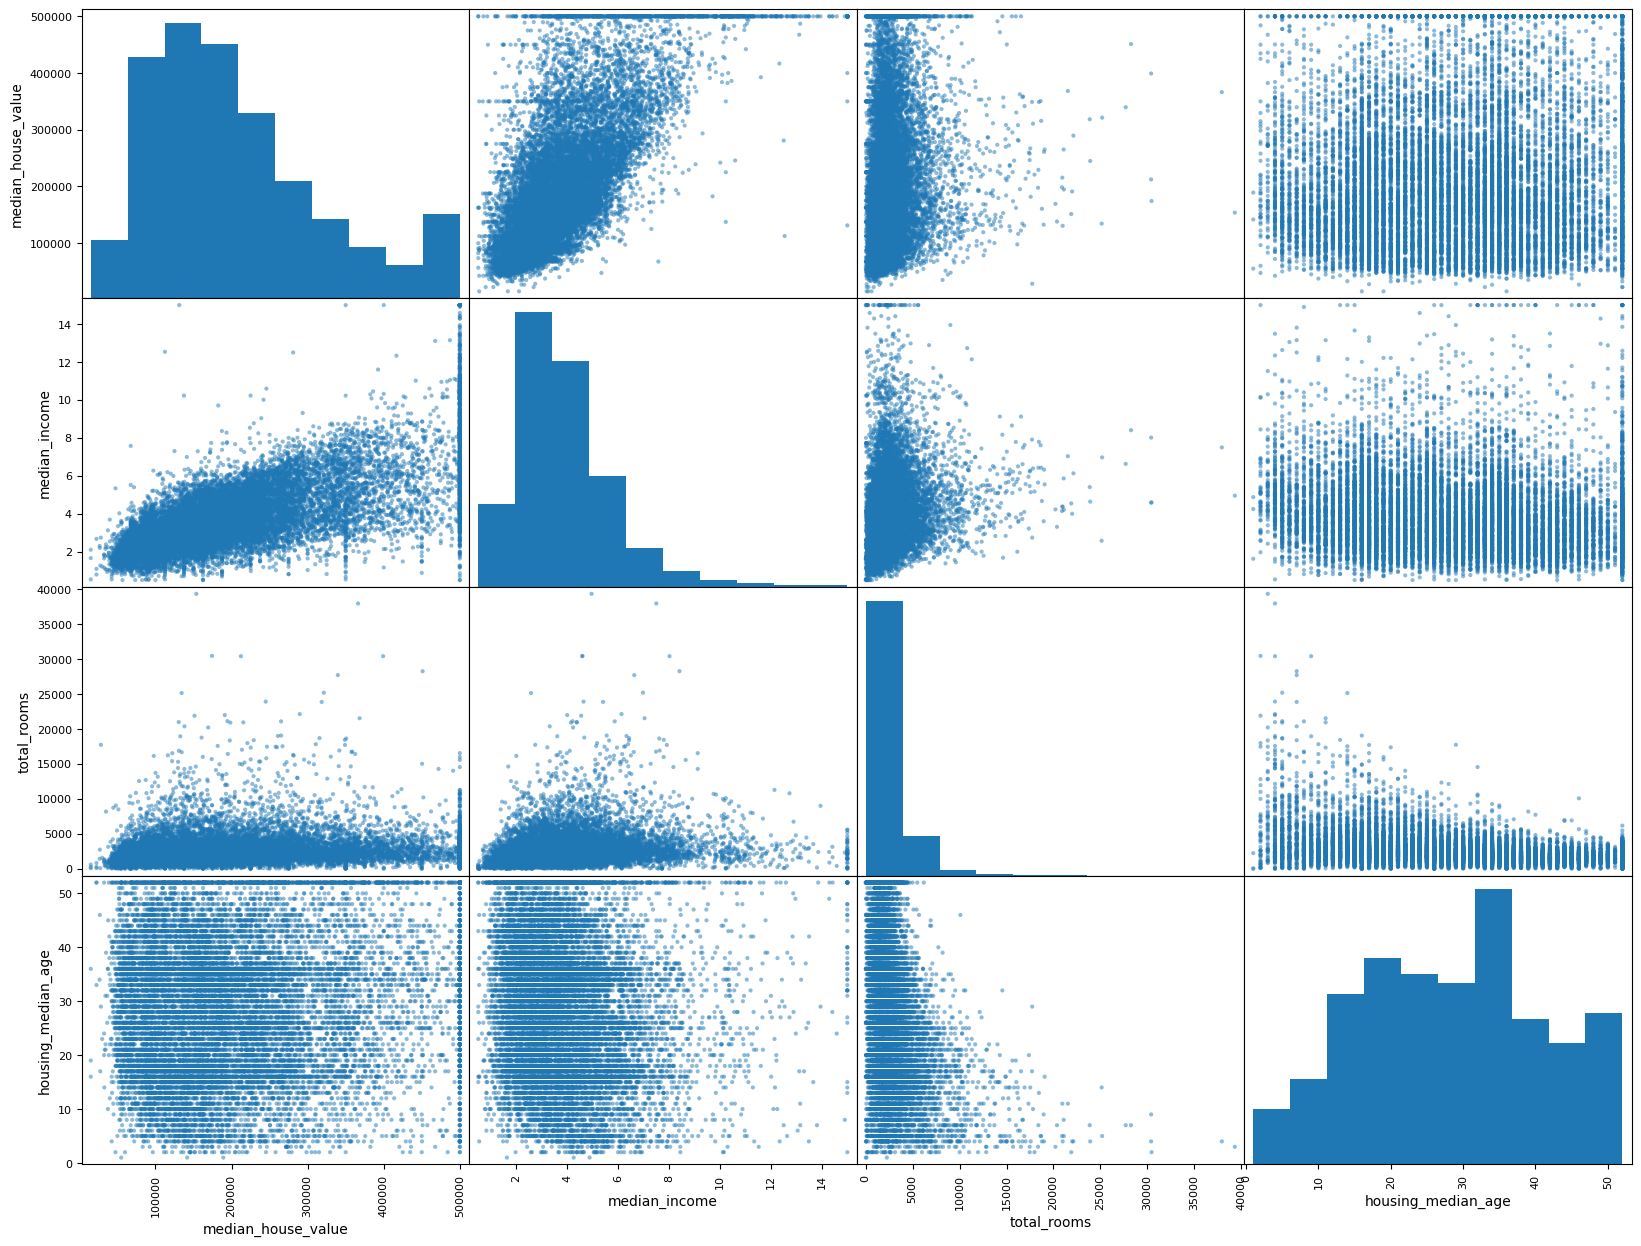

In [25]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
"housing_median_age"]
scatter_matrix(df[attributes], figsize=(20, 15))

<Axes: xlabel='median_income', ylabel='median_house_value'>

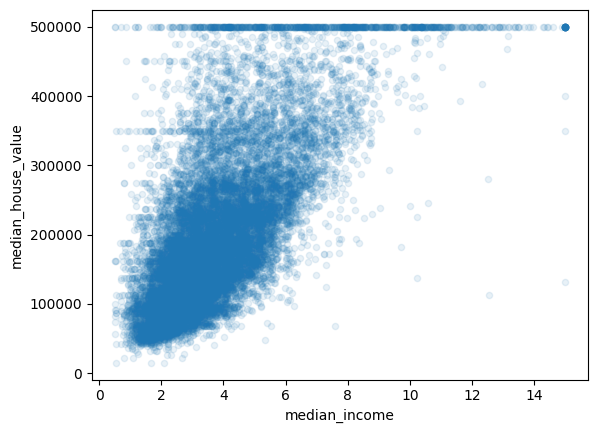

In [26]:
df.plot(kind="scatter", x="median_income", y="median_house_value",
alpha=0.1)

In [27]:
df["rooms_per_household"] = df["total_rooms"]/df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"]/df["total_rooms"]
df["population_per_household"]=df["population"]/df["households"]

In [28]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()

In [29]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687474
rooms_per_household         0.145750
total_rooms                 0.135989
housing_median_age          0.111770
households                  0.065841
total_bedrooms              0.049177
population_per_household   -0.021844
population                 -0.024765
longitude                  -0.045056
latitude                   -0.144684
bedrooms_per_room          -0.259679
Name: median_house_value, dtype: float64

In [30]:
df = strat_train_set.drop("median_house_value", axis=1)
df_labels = strat_train_set["median_house_value"].copy()

In [31]:
df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_14192\2164095440.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)


17606     351.0
15698      96.0
14650     471.0
3230      371.0
3555     1525.0
          ...  
6563      236.0
12053     294.0
13908     872.0
11159     380.0
15775     682.0
Name: total_bedrooms, Length: 16512, dtype: float64

In [32]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

In [33]:
df_num = df.drop("ocean_proximity", axis=1)

In [34]:
imputer.fit(df_num)

SimpleImputer(strategy='median')

In [35]:
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2122.    ,  434.    , 1166.    ,
        408.    ,    3.5409])

In [36]:
df_num.median().values

array([-118.51  ,   34.26  ,   29.    , 2122.    ,  434.    , 1166.    ,
        408.    ,    3.5409])

In [37]:
X = imputer.transform(df_num)

In [38]:
df_tr = pd.DataFrame(X, columns=df_num.columns)

In [39]:
housing_cat = df[["ocean_proximity"]]

In [40]:
housing_cat.head(10)

,ocean_proximity
17606,<1H OCEAN
15698,NEAR BAY
14650,NEAR OCEAN
3230,INLAND
3555,<1H OCEAN
19480,INLAND
9026,NEAR OCEAN
13685,INLAND
4937,<1H OCEAN
4861,<1H OCEAN


In [41]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()

In [42]:
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

In [43]:
housing_cat_encoded[:10]

array([[0.],
       [3.],
       [4.],
       [1.],
       [0.],
       [1.],
       [4.],
       [1.],
       [0.],
       [0.]])

In [44]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [45]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [46]:
housing_cat_1hot.toarray()

array([[1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.],
       ...,
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.]], shape=(16512, 5))

In [47]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [48]:
from sklearn.base import BaseEstimator, TransformerMixin

rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True): # no *args or **kargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self  # nothing else to do
    def transform(self, X, y=None):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(df.values)

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
('imputer', SimpleImputer(strategy="median")),
('attribs_adder', CombinedAttributesAdder()),
('std_scaler', StandardScaler()),
])
df_num_tr = num_pipeline.fit_transform(df_num)

In [50]:
from sklearn.compose import ColumnTransformer

num_attribs = list(df_num)
cat_attribs = ["ocean_proximity"]
full_pipeline = ColumnTransformer([
("num", num_pipeline, num_attribs),
("cat", OneHotEncoder(), cat_attribs),
])
housing_prepared = full_pipeline.fit_transform(df)

In [51]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, df_labels)

LinearRegression()

In [52]:
some_data = df.iloc[:5]
some_labels = df_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)
print("Predictions:", lin_reg.predict(some_data_prepared))
print("Labels:", list(some_labels))

Predictions: [209300.18149413 661078.1135578  210913.91718561  57466.84542129
 186707.41879655]
Labels: [286600.0, 500001.0, 196900.0, 46300.0, 254500.0]


In [53]:
from sklearn.metrics import mean_squared_error

housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(df_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(68321.70513040475)

In [54]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, df_labels)

DecisionTreeRegressor()

In [55]:
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(df_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

np.float64(0.0)

In [56]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree_reg, housing_prepared, df_labels,
scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

In [57]:
tree_rmse_scores

array([68042.72661143, 66814.73909138, 68660.38502476, 70523.97862198,
       71458.61626543, 75590.12170978, 68870.52021801, 73700.13144555,
       76217.24454403, 70667.64643724])

In [58]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

In [59]:
display_scores(tree_rmse_scores)

Scores: [68042.72661143 66814.73909138 68660.38502476 70523.97862198
 71458.61626543 75590.12170978 68870.52021801 73700.13144555
 76217.24454403 70667.64643724]
Mean: 71054.61099695937
Standard deviation: 3039.201958086393


In [60]:
lin_scores = cross_val_score(lin_reg, housing_prepared, df_labels,
                              scoring="neg_mean_squared_error", cv=10)

In [61]:
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [66614.9761906  66150.38653105 67344.60010664 74470.89010773
 71434.35592111 69791.47991185 65376.52916665 67643.17772272
 69655.23105926 67378.82020947]
Mean: 68586.04469270927
Standard deviation: 2633.3746663788174


In [65]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

forest_reg = RandomForestRegressor(n_estimators=10, random_state=42)
forest_reg.fit(housing_prepared, df_labels)

forest_predictions = forest_reg.predict(housing_prepared)
forest_mse = mean_squared_error(df_labels, forest_predictions)
forest_rmse = np.sqrt(forest_mse)
print(f"Forest RMSE: {forest_rmse}")

forest_scores = cross_val_score(forest_reg, housing_prepared, df_labels,
                                 scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Forest RMSE: 22167.785953077528
Scores: [51807.10627722 50027.99101259 51777.85654081 53780.43303645
 52172.540895   56843.57946505 51861.79937368 50779.18739647
 54706.25421125 54701.41876485]
Mean: 52845.81669733747
Standard deviation: 1990.2826058947257


In [68]:
import joblib

my_model = forest_reg
joblib.dump(my_model, "my_model.pkl")


['my_model.pkl']

In [69]:
my_model_loaded = joblib.load("my_model.pkl")

In [72]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {"n_estimators": [10, 30], "max_features": [4, 6]},
    {"bootstrap": [False], "n_estimators": [10], "max_features": [2, 4]},
]

forest_reg = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    forest_reg,
    param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    n_jobs=-1
)
grid_search.fit(housing_prepared, df_labels)


GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid=[{'max_features': [4, 6], 'n_estimators': [10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 4],
                          'n_estimators': [10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [73]:
grid_search.best_params_

{'max_features': 6, 'n_estimators': 30}

In [74]:
grid_search.best_estimator_

RandomForestRegressor(max_features=6, n_estimators=30, random_state=42)

In [75]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

53636.132345178004 {'max_features': 4, 'n_estimators': 10}
50914.18087147324 {'max_features': 4, 'n_estimators': 30}
52212.71667398131 {'max_features': 6, 'n_estimators': 10}
50735.58571159193 {'max_features': 6, 'n_estimators': 30}
55307.50927686617 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
52096.34827358201 {'bootstrap': False, 'max_features': 4, 'n_estimators': 10}


In [76]:
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances

array([7.60291177e-02, 7.00291114e-02, 4.32786283e-02, 1.80099861e-02,
       1.69320316e-02, 1.91271271e-02, 1.63930098e-02, 3.25510347e-01,
       4.71035002e-02, 1.08770024e-01, 9.42007658e-02, 1.17944919e-02,
       1.43358685e-01, 8.74749913e-05, 3.11482856e-03, 6.26087064e-03])

In [77]:
extra_attribs = ["rooms_per_hhold", "pop_per_hhold", "bedrooms_per_room"]
cat_encoder = full_pipeline.named_transformers_["cat"]

In [78]:
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attribs + extra_attribs + cat_one_hot_attribs
sorted(zip(feature_importances, attributes), reverse=True)

[(np.float64(0.325510346967309), 'median_income'),
 (np.float64(0.1433586852910032), 'INLAND'),
 (np.float64(0.10877002356685976), 'pop_per_hhold'),
 (np.float64(0.0942007658015029), 'bedrooms_per_room'),
 (np.float64(0.07602911766937813), 'longitude'),
 (np.float64(0.07002911144072249), 'latitude'),
 (np.float64(0.04710350023443718), 'rooms_per_hhold'),
 (np.float64(0.04327862831335652), 'housing_median_age'),
 (np.float64(0.019127127144675623), 'population'),
 (np.float64(0.018009986087175845), 'total_rooms'),
 (np.float64(0.016932031624144236), 'total_bedrooms'),
 (np.float64(0.016393009759549368), 'households'),
 (np.float64(0.011794491905279276), '<1H OCEAN'),
 (np.float64(0.00626087064373917), 'NEAR OCEAN'),
 (np.float64(0.0031148285595794705), 'NEAR BAY'),
 (np.float64(8.747499128786089e-05), 'ISLAND')]

In [79]:
final_model = grid_search.best_estimator_

In [80]:
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()
X_test_prepared = full_pipeline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

In [82]:
print(final_rmse)

47709.5259116466


In [83]:
from scipy import stats

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
print(np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
                          loc=squared_errors.mean(),
                          scale=stats.sem(squared_errors))))


[45740.92835553 49600.05240524]
